<a href="https://colab.research.google.com/github/seyiban/PCB_defect_detection/blob/feature%2Fmy-changes/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PCB 결함 탐지 - 데이터 전처리 (증강)
train/anomaly만 증강하여 클래스 불균형을 해소

In [ ]:
import zipfile

# zip 파일 위치 (Drive에 올려둔 경로)
ZIP_PATH = '/content/drive/MyDrive/dataset.zip'

# 압축 해제 경로
EXTRACT_PATH = '/content/'

print('압축 해제 중...')
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print('완료!')

# 이후 DATASET_ROOT는 아래로 설정
DATASET_ROOT = '/content/dataset'

압축 해제 중...
완료!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


셀 1. 경로 및 설정

In [ ]:
from pathlib import Path

# ============================================================
# 경로 설정 (본인 환경에 맞게 수정)
# ============================================================

# dataset/ 폴더가 있는 경로
DATASET_ROOT = '/content/drive/MyDrive/dataset'

# 처리할 카테고리
CATEGORIES = ['PCB2', 'PCB3']

# True  → train/normal 수에 맞게 자동으로 anomaly 증강 (권장)
# False → AUGMENT_MULTIPLIER 배수로 증강
AUTO_BALANCE = True

# AUTO_BALANCE = False일 때 사용
AUGMENT_MULTIPLIER = 4

RANDOM_SEED = 42

print('설정 완료')
print(f'  데이터셋 경로: {DATASET_ROOT}')

설정 완료
  데이터셋 경로: /content/drive/MyDrive/dataset


셀 2. 현재 데이터 현황 확인

In [ ]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def count_images(folder):
    folder = Path(folder)
    if not folder.exists():
        return 0
    return len([f for f in folder.iterdir() if f.suffix.lower() in IMG_EXTS])


print(f'{"카테고리":<8} {"split":<8} {"normal":>8} {"anomaly":>8} {"비율(n:a)":>12}')
print('-' * 52)

for cat in CATEGORIES:
    for split in ['train', 'val', 'test']:
        n = count_images(Path(DATASET_ROOT) / cat / split / 'normal')
        a = count_images(Path(DATASET_ROOT) / cat / split / 'anomaly')
        ratio = f'{n}:{a}'
        print(f'{cat:<8} {split:<8} {n:>8} {a:>8} {ratio:>12}')

카테고리     split      normal  anomaly      비율(n:a)
----------------------------------------------------
PCB2     train           0        0          0:0
PCB2     val             0        0          0:0
PCB2     test            0        0          0:0
PCB3     train           0        0          0:0
PCB3     val             0        0          0:0
PCB3     test            0        0          0:0


셀 3. 증강 함수 정의

In [ ]:
import random
import numpy as np
from PIL import Image, ImageEnhance

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def augment_image(img: Image.Image, seed: int) -> Image.Image:
    """
    단일 이미지에 랜덤 증강 적용
      - 회전       : -30도 ~ +30도
      - 좌우 반전  : 50% 확률
      - 상하 반전  : 30% 확률
      - 밝기 조절  : 0.6 ~ 1.4
      - 대비 조절  : 0.7 ~ 1.3
      - 채도 조절  : 0.7 ~ 1.3
    """
    random.seed(seed)

    # 회전
    angle = random.uniform(-30, 30)
    img = img.rotate(angle, resample=Image.BILINEAR, expand=False)

    # 좌우 반전
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # 상하 반전
    if random.random() > 0.7:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    # 밝기
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.6, 1.4))

    # 대비
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.3))

    # 채도
    img = ImageEnhance.Color(img).enhance(random.uniform(0.7, 1.3))

    return img


def augment_and_save(src_dir: Path, target_count: int):
    """
    src_dir 안의 이미지를 증강하여 target_count개가 될 때까지
    같은 폴더에 저장. 원본 파일은 건드리지 않음.
    """
    src_imgs = sorted([f for f in src_dir.iterdir() if f.suffix.lower() in IMG_EXTS])
    current  = len(src_imgs)
    needed   = target_count - current

    if needed <= 0:
        print(f'    증강 불필요 (현재 {current}장 >= 목표 {target_count}장)')
        return 0

    print(f'    원본 {current}장 → 목표 {target_count}장 ({needed}장 증강 중...)')

    count = 0
    while count < needed:
        for src in src_imgs:
            if count >= needed:
                break
            img = Image.open(src).convert('RGB')
            aug = augment_image(img, seed=RANDOM_SEED + count)
            save_path = src_dir / f'aug_{count:05d}{src.suffix}'
            aug.save(save_path)
            count += 1

    return count


print('증강 함수 정의 완료')

증강 함수 정의 완료


셀 4. train/anomaly 증강 실행

In [ ]:
for cat in CATEGORIES:
    print(f'\n[{cat}]')

    train_normal_dir  = Path(DATASET_ROOT) / cat / 'train' / 'normal'
    train_anomaly_dir = Path(DATASET_ROOT) / cat / 'train' / 'anomaly'

    n_normal  = count_images(train_normal_dir)
    n_anomaly = count_images(train_anomaly_dir)

    print(f'  증강 전 → normal: {n_normal}장, anomaly: {n_anomaly}장')

    if AUTO_BALANCE:
        target = n_normal
    else:
        target = n_anomaly * AUGMENT_MULTIPLIER

    aug_count = augment_and_save(train_anomaly_dir, target_count=target)

    n_anomaly_after = count_images(train_anomaly_dir)
    print(f'  증강 후 → normal: {n_normal}장, anomaly: {n_anomaly_after}장')

print('\n모든 증강 완료!')


[PCB2]
  증강 전 → normal: 0장, anomaly: 0장


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/dataset/PCB2/train/anomaly'

In [ ]:
import os

# 1단계: MyDrive 최상단 확인
print(os.listdir('/content/drive/MyDrive/'))

['프레젠테이션1.pptx', '영어 수행평가.gdoc', '수행평가', '실화냐_전자책 ver.pdf', '제목 없는 Jam (1).pdf', '제목 없는 문서 (3).gdoc', '제목 없는 Jam.pdf', '러닝페어 계획서.gdoc', 'C드라이브', 'Colab Notebooks', '제목 없는 문서 (2).gdoc', '제목 없는 문서 (1).gdoc', 'Untitled (2)', '제목 없는 문서.gdoc', 'Business Plan.gdoc', '있도록 하여 주시고 필요한 모든 편의와 보호를 베풀어 주실.pdf', '반세이-국문-성적증명서-202405151325.pdf', '반세이_.jpg', '데이터베이스_4주차.drawio', '실습01.drawio', '반세이_성균관대학교.pdf', '반도체공학_중간고사_정리.docx', 'Untitled0.ipynb', '과제 계획서.gdoc', 'Untitled2.ipynb', 'deepPCB_preprocessing.ipynb', 'Untitled3.ipynb', 'Untitled (1)', 'Untitled', 'Untitled1.ipynb', 'PCB_preprocessing_1.ipynb', 'PCB_preprocessing_2.ipynb', 'PCB_preprocessing_3.ipynb', '2026-1 교행경  중간고사 예상문제의 사본.gdoc', 'pcb_project', 'Untitled4.ipynb', 'pcb_project_22', 'Untitled5.ipynb', 'VisA_2022092

In [ ]:
# 2단계: dataset 폴더 안 확인 (dataset 이름이 다를 수 있음)
print(os.listdir('/content/drive/MyDrive/dataset/'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/dataset/'

In [ ]:
import zipfile

ZIP_PATH = '/content/drive/MyDrive/dataset.zip'
EXTRACT_PATH = '/content/'

print('압축 해제 중...')
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print('완료!')

압축 해제 중...
완료!


In [ ]:
import os
print(os.listdir('/content/'))

['.config', 'drive', 'pcb3', 'pcb2', 'sample_data']


In [ ]:
from pathlib import Path

# ============================================================
DATASET_ROOT = '/content'       # dataset/ 없이 바로 풀림
CATEGORIES   = ['pcb2', 'pcb3'] # 소문자
AUTO_BALANCE = True
AUGMENT_MULTIPLIER = 4
RANDOM_SEED  = 42

print('설정 완료')
print(f'  데이터셋 경로: {DATASET_ROOT}')

설정 완료
  데이터셋 경로: /content


In [ ]:
import os

for cat in ['pcb2', 'pcb3']:
    for split in ['train', 'val', 'test']:
        for label in ['normal', 'anomaly']:
            path = f'/content/{cat}/{split}/{label}'
            exists = os.path.exists(path)
            count = len(os.listdir(path)) if exists else 0
            print(f'{cat}/{split}/{label} → {"존재" if exists else "없음"} ({count}장)')

pcb2/train/normal → 존재 (700장)
pcb2/train/anomaly → 존재 (70장)
pcb2/val/normal → 존재 (150장)
pcb2/val/anomaly → 존재 (15장)
pcb2/test/normal → 존재 (150장)
pcb2/test/anomaly → 존재 (15장)
pcb3/train/normal → 존재 (700장)
pcb3/train/anomaly → 존재 (70장)
pcb3/val/normal → 존재 (150장)
pcb3/val/anomaly → 존재 (15장)
pcb3/test/normal → 존재 (150장)
pcb3/test/anomaly → 존재 (15장)


셀 1. 경로 및 설정

In [ ]:
from pathlib import Path

DATASET_ROOT       = '/content'
CATEGORIES         = ['pcb2', 'pcb3']
AUTO_BALANCE       = True   # train/normal 수(700장)에 맞게 anomaly 증강
AUGMENT_MULTIPLIER = 4      # AUTO_BALANCE = False일 때 사용
RANDOM_SEED        = 42

print('설정 완료')

설정 완료


셀 2. 이미지 카운트 함수

In [ ]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def count_images(folder):
    folder = Path(folder)
    if not folder.exists():
        return 0
    return len([f for f in folder.iterdir() if f.suffix.lower() in IMG_EXTS])

셀 3. 증강 함수 정의

In [ ]:
import random
import numpy as np
from PIL import Image, ImageEnhance

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def augment_image(img: Image.Image, seed: int) -> Image.Image:
    random.seed(seed)

    # 회전 -30도 ~ +30도
    angle = random.uniform(-30, 30)
    img = img.rotate(angle, resample=Image.BILINEAR, expand=False)

    # 좌우 반전 50% 확률
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # 상하 반전 30% 확률
    if random.random() > 0.7:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    # 밝기 조절
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.6, 1.4))

    # 대비 조절
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.3))

    # 채도 조절
    img = ImageEnhance.Color(img).enhance(random.uniform(0.7, 1.3))

    return img


def augment_and_save(src_dir: Path, target_count: int):
    src_imgs = sorted([f for f in src_dir.iterdir() if f.suffix.lower() in IMG_EXTS])
    current  = len(src_imgs)
    needed   = target_count - current

    if needed <= 0:
        print(f'    증강 불필요 (현재 {current}장 >= 목표 {target_count}장)')
        return 0

    print(f'    원본 {current}장 → 목표 {target_count}장 ({needed}장 증강 중...)')

    count = 0
    while count < needed:
        for src in src_imgs:
            if count >= needed:
                break
            img = Image.open(src).convert('RGB')
            aug = augment_image(img, seed=RANDOM_SEED + count)
            save_path = src_dir / f'aug_{count:05d}{src.suffix}'
            aug.save(save_path)
            count += 1

    return count

print('증강 함수 정의 완료')

증강 함수 정의 완료


셀 4. 증강 실행

In [ ]:
for cat in CATEGORIES:
    print(f'\n[{cat.upper()}]')

    train_normal_dir  = Path(DATASET_ROOT) / cat / 'train' / 'normal'
    train_anomaly_dir = Path(DATASET_ROOT) / cat / 'train' / 'anomaly'

    n_normal  = count_images(train_normal_dir)
    n_anomaly = count_images(train_anomaly_dir)

    print(f'  증강 전 → normal: {n_normal}장, anomaly: {n_anomaly}장')

    target = n_normal if AUTO_BALANCE else n_anomaly * AUGMENT_MULTIPLIER

    aug_count = augment_and_save(train_anomaly_dir, target_count=target)

    n_anomaly_after = count_images(train_anomaly_dir)
    print(f'  증강 후 → normal: {n_normal}장, anomaly: {n_anomaly_after}장')

print('\n모든 증강 완료!')


[PCB2]
  증강 전 → normal: 700장, anomaly: 70장
    원본 70장 → 목표 700장 (630장 증강 중...)
  증강 후 → normal: 700장, anomaly: 700장

[PCB3]
  증강 전 → normal: 700장, anomaly: 70장
    원본 70장 → 목표 700장 (630장 증강 중...)
  증강 후 → normal: 700장, anomaly: 700장

모든 증강 완료!


셀 5. 최종 현황 확인

In [ ]:
print(f'{"카테고리":<8} {"split":<8} {"normal":>8} {"anomaly":>8}')
print('-' * 40)

for cat in CATEGORIES:
    for split in ['train', 'val', 'test']:
        n = count_images(Path(DATASET_ROOT) / cat / split / 'normal')
        a = count_images(Path(DATASET_ROOT) / cat / split / 'anomaly')
        print(f'{cat:<8} {split:<8} {n:>8} {a:>8}')

카테고리     split      normal  anomaly
----------------------------------------
pcb2     train         700      700
pcb2     val           150       15
pcb2     test          150       15
pcb3     train         700      700
pcb3     val           150       15
pcb3     test          150       15


셀 6. 증강 이미지 시각화

/tmp/ipykernel_43485/1798049220.py:26: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43485/1798049220.py:26: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43485/1798049220.py:26: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43485/1798049220.py:26: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/py

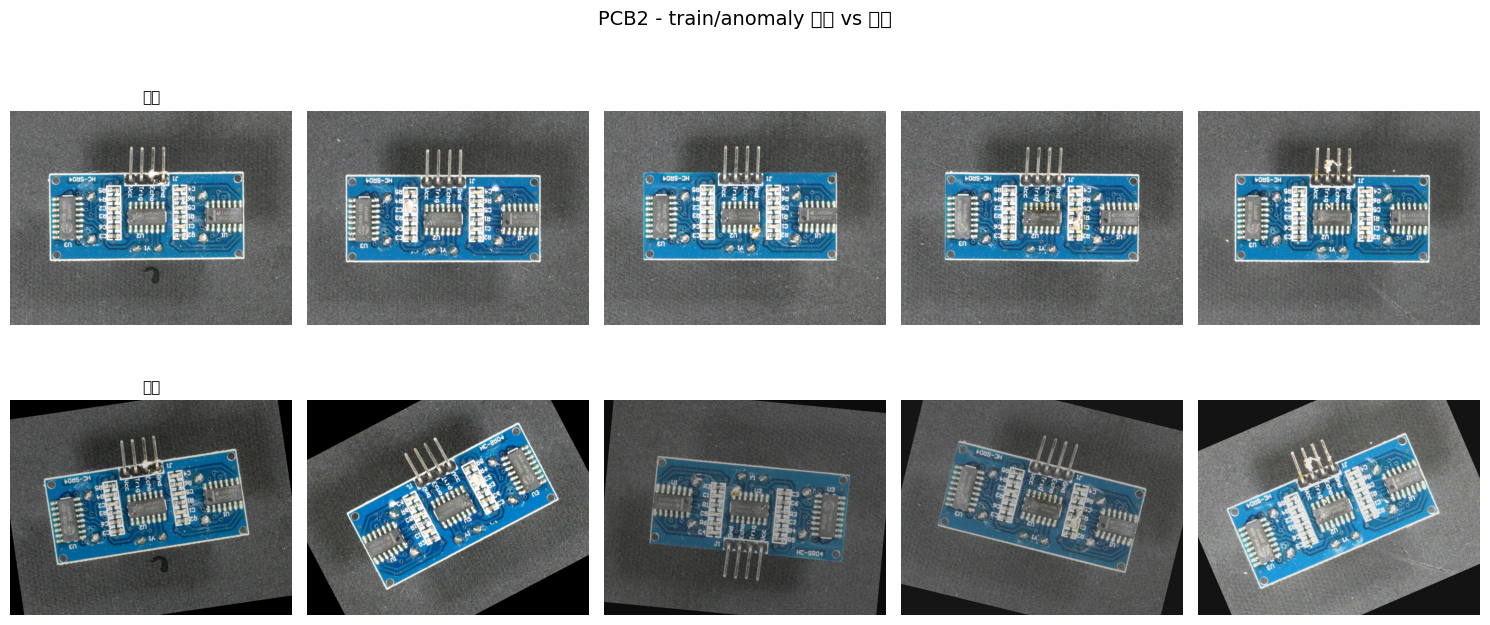

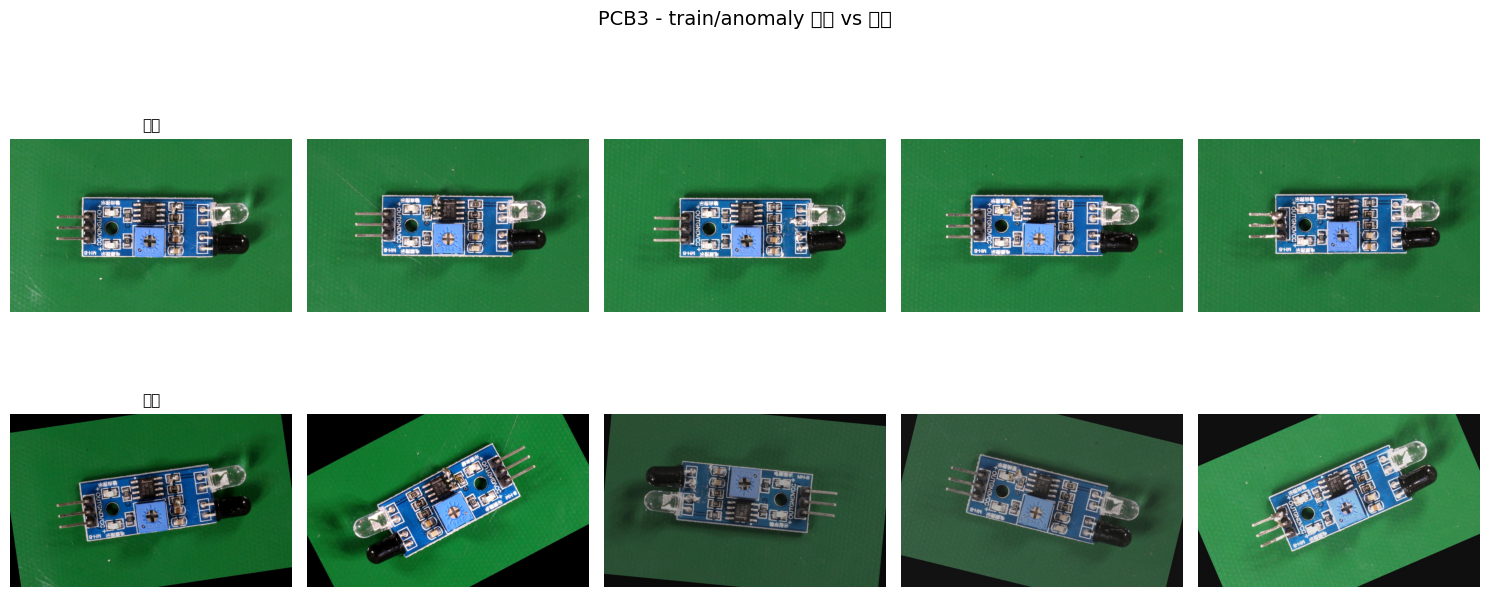

In [ ]:
import matplotlib.pyplot as plt

def show_augmentation_comparison(cat, n=5):
    anomaly_dir = Path(DATASET_ROOT) / cat / 'train' / 'anomaly'
    all_imgs = [f for f in anomaly_dir.iterdir() if f.suffix.lower() in IMG_EXTS]

    originals = sorted([f for f in all_imgs if not f.name.startswith('aug_')])[:n]
    augmented = sorted([f for f in all_imgs if f.name.startswith('aug_')])[:n]

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 7))
    fig.suptitle(f'{cat.upper()} - train/anomaly 원본 vs 증강', fontsize=14)

    for i in range(n):
        ax = axes[0][i]
        if i < len(originals):
            ax.imshow(Image.open(originals[i]).convert('RGB'))
            ax.set_title('원본' if i == 0 else '', fontsize=11)
        ax.axis('off')

        ax = axes[1][i]
        if i < len(augmented):
            ax.imshow(Image.open(augmented[i]).convert('RGB'))
            ax.set_title('증강' if i == 0 else '', fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_augmentation_comparison('pcb2')
show_augmentation_comparison('pcb3')

In [ ]:
# 전처리 노트북에서 실행 - 증강된 데이터를 Drive에 저장
import shutil

print('압축 중... (시간이 걸릴 수 있어)')
shutil.make_archive(
    '/content/drive/MyDrive/dataset_augmented',  # 저장될 파일명
    'zip',
    '/content/',                                  # 압축할 기준 경로
    '.'                                           # 압축할 폴더
)
print('저장 완료!')

압축 중... (시간이 걸릴 수 있어)


OSError: [Errno 95] Operation not supported: '/content/drive/MyDrive/영어 수행평가.gdoc'

In [ ]:
import zipfile
import os
from pathlib import Path

print('압축 중...')

with zipfile.ZipFile('/content/drive/MyDrive/dataset_augmented.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    for cat in ['pcb2', 'pcb3']:
        cat_path = Path(f'/content/{cat}')
        for file in cat_path.rglob('*'):
            if file.is_file():
                # zip 안에서의 경로: pcb2/train/anomaly/xxx.jpg
                arcname = file.relative_to('/content')
                zipf.write(file, arcname)

print('저장 완료!')

압축 중...
저장 완료!
